In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv |
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,140 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121852 files and dire

In [2]:
!pip install albumentations timm

In [5]:
import os
from glob import glob
import json
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

data_root = "/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03"
img_dir = "images"
annotations = []

def load_annotation(annot_path):
    with open(annot_path) as f:
        annot = json.load(f)
    annot['image_path'] = annot_path.replace('annotations', 'images').replace('.json', '.jpg')
    return annot

annot_paths = glob(f"{data_root}/**/*.json", recursive=True)

with ThreadPoolExecutor(max_workers=128) as executor:
    annotations = list(tqdm(executor.map(load_annotation, annot_paths), total=len(annot_paths)))

100%|██████████| 32253/32253 [02:54<00:00, 184.60it/s]


In [6]:
glob(f"{data_root}/**/*.json", recursive=True)

['/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/annotations/기타/1348731.json',
 '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/annotations/기타/1348803.json',
 '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/annotations/기타/1347906.json',
 '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/annotations/기타/1348565.json',
 '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/annotations/기타/1351931.json',
 '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/annotations/기타/1352556.json',
 '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/annotations/기타/1348305.json',
 '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/annotations/기타

In [7]:
annotations[0]

{'이미지 정보': {'이미지 식별자': 1348731,
  '이미지 높이': 1049,
  '이미지 파일명': 'dalfjlwe-(208).jpg',
  '이미지 너비': 800},
 '데이터셋 정보': {'파일 생성일자': '2020-12-08 13:12:25',
  '데이터셋 상세설명': {'렉트좌표': {'아우터': [{}],
    '하의': [{}],
    '원피스': [{'X좌표': 228.5, 'Y좌표': 214.459, '가로': 329, '세로': 650}],
    '상의': [{}]},
   '폴리곤좌표': {'아우터': [{}],
    '하의': [{}],
    '원피스': [{'Y좌표47': 305.542,
      'Y좌표44': 470.51,
      'Y좌표43': 494.506,
      'Y좌표46': 353.533,
      'Y좌표45': 405.523,
      'Y좌표40': 550.495,
      'Y좌표42': 524.5,
      'Y좌표41': 534.498,
      'X좌표39': 273.0,
      'X좌표38': 277.0,
      'X좌표37': 282.0,
      'X좌표36': 288.0,
      'X좌표35': 254.0,
      'X좌표34': 296.0,
      'X좌표33': 317.0,
      'X좌표32': 321.0,
      'X좌표31': 360.0,
      'X좌표30': 378.0,
      'Y좌표37': 621.482,
      'Y좌표36': 702.466,
      'X좌표8': 379.0,
      'Y좌표39': 572.491,
      'X좌표9': 387.0,
      'Y좌표38': 565.492,
      'Y좌표33': 864.435,
      'Y좌표32': 844.439,
      'Y좌표35': 861.436,
      'Y좌표34': 865.435,
      'Y좌표31': 861.4

In [8]:
annotations[0]['이미지 정보']

{'이미지 식별자': 1348731,
 '이미지 높이': 1049,
 '이미지 파일명': 'dalfjlwe-(208).jpg',
 '이미지 너비': 800}

In [9]:
annotations[0]['데이터셋 정보'].keys()

dict_keys(['파일 생성일자', '데이터셋 상세설명', '파일 번호', '파일 이름'])

In [10]:
annotations[0]['데이터셋 정보']['데이터셋 상세설명'].keys()

dict_keys(['렉트좌표', '폴리곤좌표', '라벨링'])

In [11]:
annotations[0]['데이터셋 정보']['데이터셋 상세설명']['렉트좌표']

{'아우터': [{}],
 '하의': [{}],
 '원피스': [{'X좌표': 228.5, 'Y좌표': 214.459, '가로': 329, '세로': 650}],
 '상의': [{}]}

In [12]:
annotations[0]['데이터셋 정보']['데이터셋 상세설명']['라벨링']

{'스타일': [{}],
 '아우터': [{}],
 '하의': [{}],
 '원피스': [{'색상': '그레이', '소매기장': '긴팔'}],
 '상의': [{}]}

In [13]:
annotations[0].keys()

dict_keys(['이미지 정보', '데이터셋 정보', 'image_path'])

In [14]:
main_categories = ['아우터', '하의', '원피스', '상의']

In [15]:
from ast import main
from collections import defaultdict

new_annotations = []

detail_category_map = defaultdict(int)
color_map = defaultdict(int)
fit_map = defaultdict(int)
length_map = defaultdict(int)

for annot in tqdm(annotations):
    image_path = annot['image_path']
    coord_info = annot['데이터셋 정보']['데이터셋 상세설명']['렉트좌표']
    main_info = annot['데이터셋 정보']['데이터셋 상세설명']['라벨링']

    image_id = 0
    for main_cat in main_categories:
        main_category_info_list = main_info[main_cat]
        main_category_box_list = coord_info[main_cat]

        for box_info, main_category_info in zip(main_category_box_list, main_category_info_list):
            if len(box_info) < 1:
                continue
            if len(main_category_info) < 1:
                continue
            x1 = max(int(box_info['X좌표']), 0)
            y1 = max(int(box_info['Y좌표']), 0)
            w = int(box_info['가로'])
            h = int(box_info['세로'])

            x2 = x1 + w
            y2 = y1 + h

            box = [x1, y1, x2, y2]

            flag = True
            for key in ['카테고리', '색상', '기장', '핏']:
                if key not in main_category_info:
                    flag = False
                    break

            if not flag:
                continue

            detail_category = main_category_info['카테고리']
            color = main_category_info['색상']
            fit = main_category_info['핏']
            length = main_category_info['기장']

            detail_category_map[detail_category] += 1
            color_map[color] += 1
            fit_map[fit] += 1
            length_map[length] += 1

            new_annotations.append(
                {
                    'image_path': image_path,
                    'image_id': image_id,
                    'box': box,
                    'detail_category': detail_category,
                    'color': color,
                    'fit': fit,
                    'length': length
                }
            )

            image_id += 1

100%|██████████| 32253/32253 [00:01<00:00, 30098.09it/s]


In [16]:
new_annotations[:5]

[{'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/밀리터리/38617.jpg',
  'image_id': 0,
  'box': [188, 0, 655, 796],
  'detail_category': '재킷',
  'color': '네이비',
  'fit': '루즈',
  'length': '롱'},
 {'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/밀리터리/179944.jpg',
  'image_id': 0,
  'box': [160, 5, 677, 786],
  'detail_category': '점퍼',
  'color': '카키',
  'fit': '루즈',
  'length': '하프'},
 {'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/밀리터리/284349.jpg',
  'image_id': 0,
  'box': [143, 0, 710, 639],
  'detail_category': '셔츠',
  'color': '그레이',
  'fit': '노멀',
  'length': '노멀'},
 {'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/밀리터리/202462.jpg',
  'image_id': 0,
  'box': [42, 27, 748, 740],
  'detail_category': '

In [17]:
print(f"Annotations length: {len(new_annotations)}")

Annotations length: 37805


In [18]:
print(detail_category_map)
print(color_map)
print(fit_map)
print(length_map)

defaultdict(<class 'int'>, {'재킷': 1588, '점퍼': 469, '셔츠': 1315, '티셔츠': 4276, '패딩': 247, '팬츠': 6648, '청바지': 4827, '짚업': 169, '드레스': 5131, '조거팬츠': 206, '후드티': 390, '코트': 984, '탑': 1383, '베스트': 515, '스커트': 3337, '블라우스': 2879, '니트웨어': 2129, '점프수트': 174, '가디건': 947, '래깅스': 151, '브라탑': 40})
defaultdict(<class 'int'>, {'네이비': 2204, '카키': 1047, '그레이': 2148, '옐로우': 624, '베이지': 4425, '블랙': 6025, '화이트': 6936, '브라운': 1667, '그린': 654, '민트': 441, '스카이블루': 2674, '블루': 2872, '실버': 668, '오렌지': 491, '라벤더': 470, '퍼플': 488, '핑크': 2246, '와인': 556, '레드': 741, '네온': 177, '골드': 251})
defaultdict(<class 'int'>, {'루즈': 11444, '노멀': 17603, '오버사이즈': 1442, '스키니': 2786, '타이트': 1155, '와이드': 2605, '벨보텀': 770})
defaultdict(<class 'int'>, {'롱': 5484, '하프': 1607, '노멀': 7905, '노말': 1551, '발목': 10095, '미디': 4237, '미니': 3461, '크롭': 684, '니렝스': 2173, '맥시': 608})


In [19]:
def get_class_count(class_map):
    class_list = []
    class_count = []
    for k, v in class_map.items():
        class_list.append(k)
        class_count.append(v)
    return class_list, class_count

In [20]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Clear cache and rebuild
fm.fontManager.__init__()  # Reset font manager

# Verify the font exists
nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print(nanum_fonts)  # Should show NanumBarunGothic or similar

['NanumMyeongjo', 'NanumBarunGothic', 'NanumMyeongjo', 'NanumGothic', 'NanumSquareRound', 'NanumSquare', 'NanumBarunGothic', 'NanumGothicCoding', 'NanumSquare', 'NanumGothic', 'NanumSquareRound', 'NanumGothicCoding']


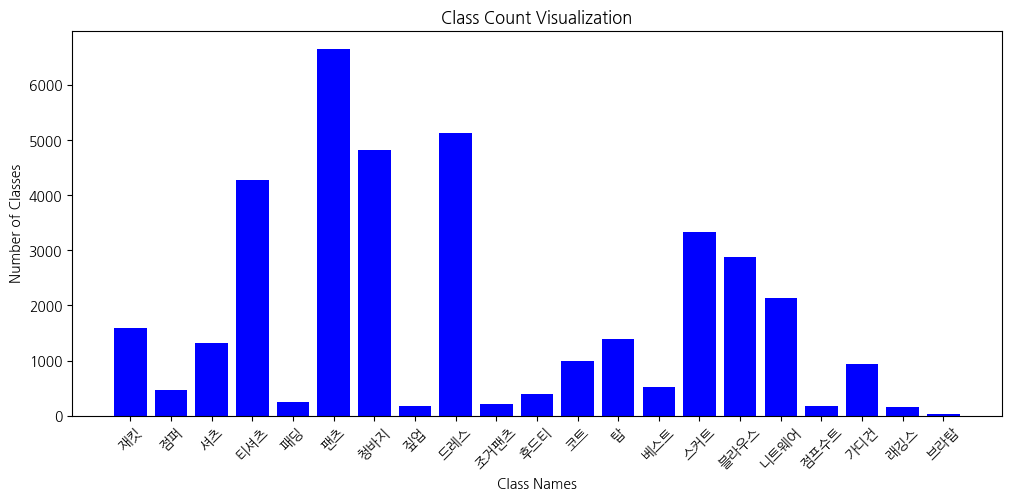

In [21]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic')
class_list, class_count = get_class_count(detail_category_map)
plt.figure(figsize=(12, 5))

plt.bar(class_list, class_count, color='blue')

plt.title('Class Count Visualization')
plt.xlabel('Class Names')
plt.ylabel('Number of Classes')
plt.xticks(rotation=45)
plt.show()

In [22]:
detail_category_list = list(detail_category_map.keys())
color_list = list(color_map.keys())
fit_list = list(fit_map.keys())
length_list = list(length_map.keys())

In [23]:
detail_category_list

['재킷',
 '점퍼',
 '셔츠',
 '티셔츠',
 '패딩',
 '팬츠',
 '청바지',
 '짚업',
 '드레스',
 '조거팬츠',
 '후드티',
 '코트',
 '탑',
 '베스트',
 '스커트',
 '블라우스',
 '니트웨어',
 '점프수트',
 '가디건',
 '래깅스',
 '브라탑']

In [24]:
annotations = new_annotations

In [25]:
annotations

[{'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/밀리터리/38617.jpg',
  'image_id': 0,
  'box': [188, 0, 655, 796],
  'detail_category': '재킷',
  'color': '네이비',
  'fit': '루즈',
  'length': '롱'},
 {'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/밀리터리/179944.jpg',
  'image_id': 0,
  'box': [160, 5, 677, 786],
  'detail_category': '점퍼',
  'color': '카키',
  'fit': '루즈',
  'length': '하프'},
 {'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/밀리터리/284349.jpg',
  'image_id': 0,
  'box': [143, 0, 710, 639],
  'detail_category': '셔츠',
  'color': '그레이',
  'fit': '노멀',
  'length': '노멀'},
 {'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/밀리터리/202462.jpg',
  'image_id': 0,
  'box': [42, 27, 748, 740],
  'detail_category': '

In [26]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class JsonDataset(Dataset):
    def __init__(self, annotations, detail_category_list, color_list, fit_list, length_list, margin=0.1, transform=None):
        self.annotations = annotations
        self.detail_category_list = detail_category_list
        self.color_list = color_list
        self.fit_list = fit_list
        self.length_list = length_list
        self.margin = margin
        self.transform = transform

        self.normal_data = None

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        annot = self.annotations[index]
        image_path = os.path.join(annot['image_path'])
        image = Image.open(image_path).convert("RGB")
        box = annot['box']

        w = box[2] - box[0]
        h = box[3] - box[1]

        new_box = [int(box[0] - w * self.margin),
                   int(box[1] - h * self.margin),
                   int(box[2] + w * self.margin),
                   int(box[3] + h * self.margin)]

        cropped_image = image.crop(new_box)

        detail = self.detail_category_list.index(annot['detail_category'])
        color = self.color_list.index(annot['color'])
        fit = self.fit_list.index(annot['fit'])
        length = self.length_list.index(annot['length'])

        target_list = [detail, color, fit, length]
        target_list = torch.tensor(target_list).to(torch.long)

        if self.transform:
            try:
                cropped_image = self.transform(image=np.array(cropped_image))['image']
                image = self.transform(image=np.array(image))['image']
                self.normal_data = [cropped_image, target_list, image]
            except:
                cropped_image, target_list, image = self.normal_data
                print(index, annot)


        return cropped_image, target_list, image

In [27]:
dataset = JsonDataset(annotations=annotations, detail_category_list=detail_category_list, color_list=color_list, fit_list=fit_list, length_list=length_list)

In [37]:
data = dataset[3]

In [39]:
data

(<PIL.Image.Image image mode=RGB size=846x855>,
 tensor([0, 1, 0, 3]),
 <PIL.Image.Image image mode=RGB size=800x800>)

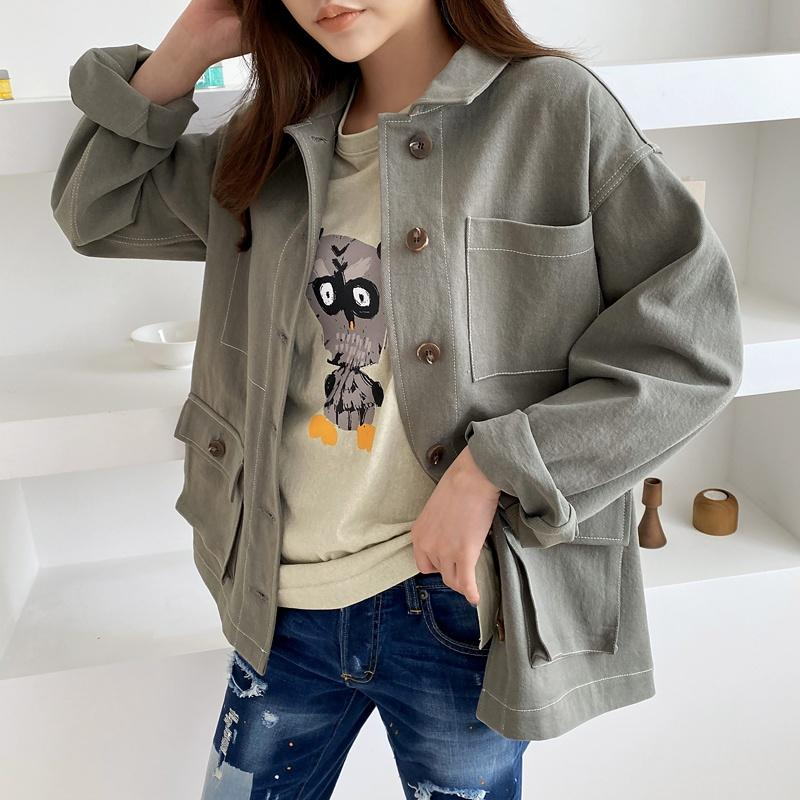

In [41]:
data[2]

In [43]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def draw_images(images, classes):
    plt.rc('font', family='NanumGothic')

    fig, axs = plt.subplots(2, 4, figsize=(12, 6))

    for i, ax in enumerate(axs.flat):
        if i > len(images):
            break
        ax.imshow(images[i])
        ax.set_title(classes[i])

    plt.tight_layout()
    plt.show()

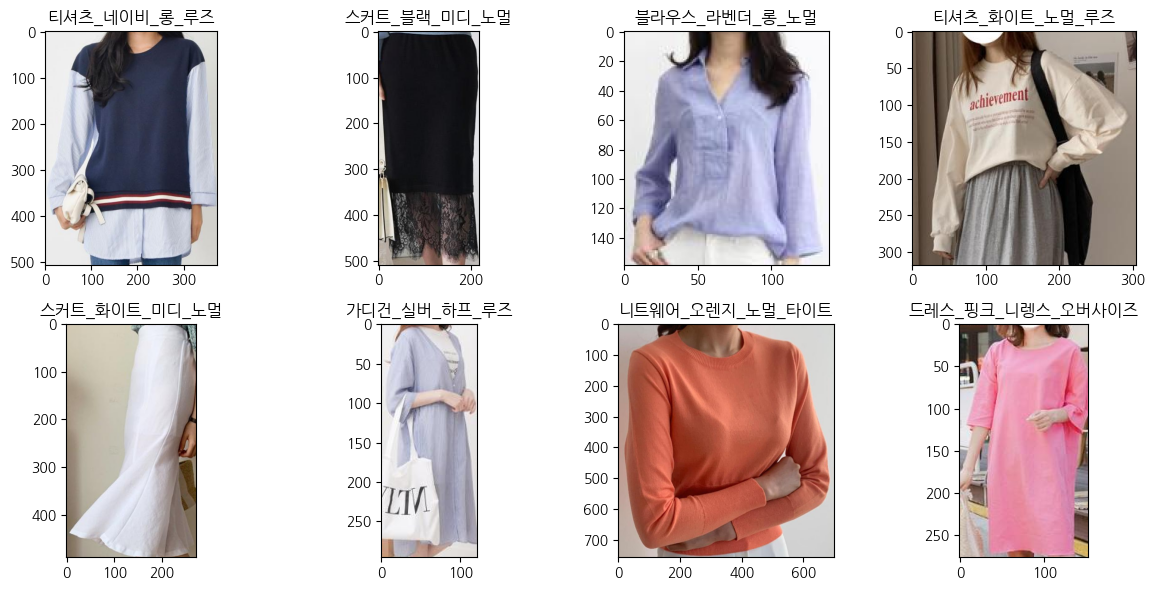

In [44]:
from PIL import Image
import numpy as np
import random

random.shuffle(annotations)

sample_images = []
sample_classes = []
sample_count = 0
max_cnt = 8


for annot in annotations:
    class_str = f"{annot['detail_category']}_{annot['color']}_{annot['length']}_{annot['fit']}"
    sample_classes.append(class_str)
    image_path = annot['image_path']
    box = annot['box']
    image = Image.open(image_path).convert('RGB')
    cropped_image = image.crop(box)

    sample_images.append(np.array(cropped_image))
    sample_count += 1
    if sample_count > max_cnt:
        break

draw_images(sample_images, sample_classes)

In [46]:
len_annot = len(annotations)
train_annot = annotations[ : int(len_annot * 0.9)]
val_annot = annotations[int(len_annot * 0.9) : ]

print(f"학습 데이터 개수: {len(train_annot)}")
print(f"검증 데이터 개수: {len(val_annot)}")

학습 데이터 개수: 34024
검증 데이터 개수: 3781


In [47]:
hyper_params = {
    'num_epochs': 10,
    'lr': 0.0001,
    'image_size': 224,
    'train_batch_size': 42,
    'val_batch_size': 16,
    'print_freq': 0.1
}

In [49]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

sample_tranform = A.Compose([
    A.ShiftScaleRotate(rotate_limit=15, shift_limit=0.05, scale_limit=0.1, p=0.5, border_mode=0),
    A.HorizontalFlip(p=0.5),
    A.LongestMaxSize(max_size=hyper_params['image_size'], always_apply=True),
    A.PadIfNeeded(min_height=hyper_params['image_size'], min_width=hyper_params['image_size'], always_apply=True, border_mode=0)
])

sample_dataset = JsonDataset(annotations=annotations, detail_category_list=detail_category_list, color_list=color_list, fit_list=fit_list,
                             length_list=length_list, transform=sample_tranform)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_760/1557537472.py:7: UserWarning: Argument(s) 'always_apply' are not valid for transform MaxSizeTransform
  A.LongestMaxSize(max_size=hyper_params['image_size'], always_apply=True),
/tmp/ipykernel_760/1557537472.py:8: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=hyper_params['image_size'], min_width=hyper_params['image_size'], always_apply=True, border_mode=0)


In [50]:
sample = sample_dataset[1]
sample

(array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]], dtype=uint8),
 tensor([14,  5,  1,  5]),
 array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         

In [54]:
sample[1]

tensor([14,  5,  1,  5])

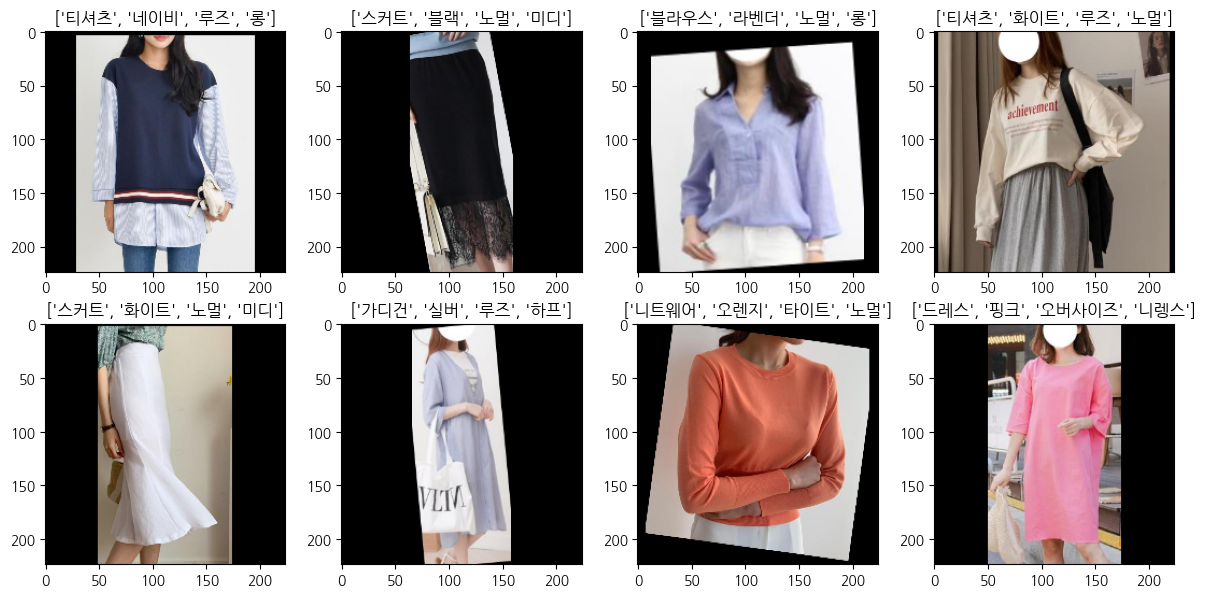

In [55]:
transformed_images = []
targets = []

max = 8
for idx, (cropped_image, target, image) in enumerate(sample_dataset):
    if idx == max:
        break
    transformed_images.append(cropped_image)
    targets.append(target.tolist())

target_classes = []
for target in targets:
    classes = []
    classes.append(detail_category_list[target[0]])
    classes.append(color_list[target[1]])
    classes.append(fit_list[target[2]])
    classes.append(length_list[target[3]])

    target_classes.append(classes)

draw_images(transformed_images, target_classes)

In [56]:
train_transform = A.Compose([
    A.ShiftScaleRotate(rotate_limit=15, shift_limit=0.05, scale_limit=0.1, p=0.5, border_mode=0),
    A.HorizontalFlip(p=0.5),
    A.LongestMaxSize(max_size=hyper_params['image_size'], always_apply=True),
    A.PadIfNeeded(min_height=hyper_params['image_size'], min_width=hyper_params['image_size'], always_apply=True, border_mode=0),
    A.Normalize(p=1.0, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
train_dataset = JsonDataset(annotations=train_annot, detail_category_list=detail_category_list, color_list=color_list,
                            fit_list=fit_list, length_list=length_list, transform=train_transform)
train_dataloader = torch.utils.data.DataLoader(train_dataset, num_workers=2, batch_size=hyper_params['train_batch_size'], shuffle=True)

valid_transform = A.Compose([
    A.LongestMaxSize(max_size=hyper_params['image_size'], always_apply=True),
    A.PadIfNeeded(min_height=hyper_params['image_size'], min_width=hyper_params['image_size'], always_apply=True, border_mode=0),
    A.Normalize(p=1.0, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
valid_dataset = JsonDataset(annotations=val_annot, detail_category_list=detail_category_list, color_list=color_list,
                            fit_list=fit_list, length_list=length_list, transform=valid_transform)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, num_workers=2, batch_size=hyper_params['val_batch_size'], shuffle=False)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_760/1617269438.py:4: UserWarning: Argument(s) 'always_apply' are not valid for transform MaxSizeTransform
  A.LongestMaxSize(max_size=hyper_params['image_size'], always_apply=True),
/tmp/ipykernel_760/1617269438.py:5: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=hyper_params['image_size'], min_width=hyper_params['image_size'], always_apply=True, border_mode=0),
/tmp/ipykernel_760/1617269438.py:14: UserWarning: Argument(s) 'always_apply' are not valid for transform MaxSizeTransform
  A.LongestMaxSize(max_size=hyper_params['image_size'], always_apply=True),
/tmp/ipykernel_760/1617269438.py:15: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  A.PadIfNeeded(m

In [58]:
import timm
timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [64]:
import torch.nn as nn

class BranchClassifier(nn.Module):
    def __init__(self, num_classes_list, num_branches=4, model_name='efficientnet_b0', pretrained=True):
        super(BranchClassifier, self).__init__()

        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1280, 256),
                nn.SiLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes_list[i])
            )
            for i in range(num_branches)
        ])

    def forward(self, x):
        features = self.backbone(x)
        outputs = [branch(features) for branch in self.branches]

        return outputs

In [65]:
num_classes_list = [len(detail_category_list), len(color_list), len(fit_list), len(length_list)]
num_branches = 4
model = BranchClassifier(num_classes_list=num_classes_list, num_branches=num_branches, model_name='efficientnet_b0', pretrained=True)

In [67]:
sample_input = torch.rand(1, 3, 224, 224)
sample_output = model(sample_input)
sample_output

[tensor([[ 0.0676,  0.0763, -0.0430, -0.0456, -0.0073,  0.0456,  0.0066, -0.0759,
          -0.0140,  0.0638,  0.0481,  0.0100,  0.0624, -0.0102,  0.0156, -0.0498,
           0.0186,  0.0428, -0.0174, -0.0253,  0.0234]],
        grad_fn=<AddmmBackward0>),
 tensor([[ 0.0095, -0.0002,  0.0502,  0.0217, -0.0686,  0.0161,  0.0815, -0.0047,
           0.0419,  0.0168, -0.0542, -0.0392, -0.0508, -0.0226,  0.0957,  0.0255,
           0.0474, -0.1053,  0.0854, -0.0384,  0.0133]],
        grad_fn=<AddmmBackward0>),
 tensor([[-0.1011,  0.0580, -0.0553,  0.0256, -0.0238, -0.0844, -0.0063]],
        grad_fn=<AddmmBackward0>),
 tensor([[-0.0396, -0.0749, -0.0383, -0.0110, -0.0573, -0.0301, -0.0540, -0.0195,
          -0.0768,  0.0451]], grad_fn=<AddmmBackward0>)]

In [68]:
print(f"첫 번째 output shape: {sample_output[0].shape}")
print(f"두 번째 output shape: {sample_output[1].shape}")
print(f"세 번째 output shape: {sample_output[2].shape}")
print(f"네 번째 output shape: {sample_output[3].shape}")

첫 번째 output shape: torch.Size([1, 21])
두 번째 output shape: torch.Size([1, 21])
세 번째 output shape: torch.Size([1, 7])
네 번째 output shape: torch.Size([1, 10])


In [69]:
print(f"첫 번째 클래스 개수: {len(detail_category_list)}")
print(f"두 번째 클래스 개수: {len(color_list)}")
print(f"세 번째 클래스 개수: {len(fit_list)}")
print(f"네 번째 클래스 개수: {len(length_list)}")

첫 번째 클래스 개수: 21
두 번째 클래스 개수: 21
세 번째 클래스 개수: 7
네 번째 클래스 개수: 10


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score